# EGA · PGA · CGA: Parallel Structures in Geometric Algebra
### Using the Kingdon Python Library

> **George Papagiannakis** · Elements / ORamaVR  
> References: Dorst et al. 2007, Gunn 2011, De Keninck & Dorst 2019, Lengyel 2024  

---

This notebook explores the **three principal Geometric Algebra models** used in computer graphics and XR:

| Model | Algebra | Dimensions | Key feature |
|-------|---------|-----------|-------------|
| **EGA** | Cl(3,0,0) | 3D Euclidean | Rotors, pure rotations, SH rotation |
| **PGA** | Cl(3,0,1) | 3D Projective | Motors = rotors + translators, rigid body |
| **CGA** | Cl(4,1,0) | 3D Conformal | Spheres, circles, inversions as first-class objects |

All three share the same **sandwich product** structure `X ↦ M X M̃` for transformations,  
but differ in what geometric objects they represent natively and how translations are encoded.

**Kingdon** (`pip install kingdon`) is a symbolic-and-numeric GA library by Martin Roelfs  
with lazy multivector evaluation, operator overloading, and optional ganja.js visualization.

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install kingdon numpy matplotlib

from kingdon import Algebra
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

print(f"Kingdon version: {__import__('kingdon').__version__}")
print("All imports OK")

Kingdon version: 1.4.0
All imports OK


---
## Part 1 — EGA: Euclidean Geometric Algebra  `Cl(3, 0, 0)`

The **Euclidean model** lifts 3D Euclidean space into the 8-dimensional Clifford algebra Cl(3,0,0).

### Basis blades

| Grade | Blades | Count | Geometric meaning |
|-------|--------|-------|------------------|
| 0 | `e` (scalar) | 1 | Scale |
| 1 | `e1, e2, e3` | 3 | Euclidean vectors |
| 2 | `e12, e13, e23` | 3 | Bivectors = oriented planes / rotation generators |
| 3 | `e123` (pseudoscalar I₃) | 1 | Volume / Hodge dual |

Metric: `eᵢ · eᵢ = +1`, `eᵢ · eⱼ = 0` (i≠j)

**Key products:**
- `a * b` — geometric product (encodes both inner and outer)
- `a ^ b` — outer/wedge product (grade-raising)
- `a | b` — inner/dot product (grade-lowering, symmetric)
- `~a` — reversion (grade-k blade → sign (-1)^{k(k-1)/2})

In [2]:
# ── EGA Algebra Setup ─────────────────────────────────────────────────────────
ega = Algebra(3, 0, 0)   # Cl(3,0,0)

# Grade-1 basis vectors
e1  = ega.multivector({'e1': 1})
e2  = ega.multivector({'e2': 1})
e3  = ega.multivector({'e3': 1})

# Grade-2 bivectors (rotation generators)
e12 = e1 * e2   # rotation in xy-plane (around z)
e13 = e1 * e3   # rotation in xz-plane (around y)
e23 = e2 * e3   # rotation in yz-plane (around x)

# Grade-3 pseudoscalar
I3  = e1 * e2 * e3

print("EGA Cl(3,0,0) — basis blades:")
print(f"  Scalars (grade 0): e = 1")
print(f"  Vectors (grade 1): {e1}, {e2}, {e3}")
print(f"  Bivectors (grade 2): {e12}, {e13}, {e23}")
print(f"  Pseudoscalar (grade 3): I3 = {I3}")

print("\nMetric (eᵢ² = +1):")
print(f"  e1*e1 = {e1*e1},  e2*e2 = {e2*e2},  e3*e3 = {e3*e3}")
print(f"  e12² = {e12*e12}  (bivector squares to -1: rotation generator)")
print(f"  I3² = {I3*I3}  (pseudoscalar squares to -1 in Cl(3,0))")

EGA Cl(3,0,0) — basis blades:
  Scalars (grade 0): e = 1
  Vectors (grade 1): 1 𝐞₁, 1 𝐞₂, 1 𝐞₃
  Bivectors (grade 2): 1 𝐞₁₂, 1 𝐞₁₃, 1 𝐞₂₃
  Pseudoscalar (grade 3): I3 = 1 𝐞₁₂₃

Metric (eᵢ² = +1):
  e1*e1 = 1,  e2*e2 = 1,  e3*e3 = 1
  e12² = -1  (bivector squares to -1: rotation generator)
  I3² = -1  (pseudoscalar squares to -1 in Cl(3,0))


In [3]:
# ── EGA Products: inner, outer, geometric ────────────────────────────────────
a = e1 + e2              # vector: (1,1,0)
b = e2 + e3              # vector: (0,1,1)

print("Vectors:")
print(f"  a = {a}")
print(f"  b = {b}")

print("\nProducts:")
print(f"  a | b  (inner)   = {a | b}   ← scalar = a·b = 1")
print(f"  a ^ b  (outer)   = {a ^ b}   ← bivector = oriented area")
print(f"  a * b  (geometric) = {a * b}")
print(f"  Verify: a*b = (a|b) + (a^b) = {(a|b) + (a^b)}")

print("\nReversion (~): reverses blade ordering")
print(f"  ~e12 = {~e12}   (sign flip for grade-2)")
print(f"  ~I3  = {~I3}    (sign flip for grade-3)")

print("\nHodge dual via pseudoscalar multiplication:")
print(f"  e1 * I3 = {e1 * I3}   (vector → bivector dual = e23)")
print(f"  e12 * I3 = {e12 * I3}  (bivector → vector dual = e3)")

Vectors:
  a = 1 𝐞₁ + 1 𝐞₂
  b = 1 𝐞₂ + 1 𝐞₃

Products:
  a | b  (inner)   = 1   ← scalar = a·b = 1
  a ^ b  (outer)   = 1 𝐞₁₂ + 1 𝐞₁₃ + 1 𝐞₂₃   ← bivector = oriented area
  a * b  (geometric) = 1 + 1 𝐞₁₂ + 1 𝐞₁₃ + 1 𝐞₂₃
  Verify: a*b = (a|b) + (a^b) = 1 + 1 𝐞₁₂ + 1 𝐞₁₃ + 1 𝐞₂₃

Reversion (~): reverses blade ordering
  ~e12 = -1 𝐞₁₂   (sign flip for grade-2)
  ~I3  = -1 𝐞₁₂₃    (sign flip for grade-3)

Hodge dual via pseudoscalar multiplication:
  e1 * I3 = 1 𝐞₂₃   (vector → bivector dual = e23)
  e12 * I3 = -1 𝐞₃  (bivector → vector dual = e3)


In [4]:
# ── EGA Rotors: R = exp(-θ/2 · B̂) ──────────────────────────────────────────
#
# A rotor in EGA encodes a rotation by angle θ around the axis dual to bivector B:
#   R = cos(θ/2) + sin(θ/2)·B̂  where B̂ is a unit bivector
#   Action: v' = R v R̃  (sandwich product)

def ega_rotor(bivector, angle_deg):
    """Build EGA rotor for rotation by angle_deg around axis given by unit bivector."""
    theta = math.radians(angle_deg)
    c, s = math.cos(theta / 2), math.sin(theta / 2)
    name = list(bivector.keys())[0]
    return ega.multivector({'e': c, ega.bin2canon[name]: -s})

# Rotation by 90° around the z-axis (e12 bivector plane)
theta_deg = 90
c = math.cos(math.radians(theta_deg / 2))
s = math.sin(math.radians(theta_deg / 2))
R_z90 = ega.multivector({'e': c, 'e12': -s})

print("EGA Rotor — 90° rotation around z-axis (e12 plane):")
print(f"  R = cos(45°) - sin(45°)·e12 = {R_z90}")
print(f"  R·R̃ = {R_z90 * ~R_z90}  (unit versor check)")

# Rotate basis vectors
print("\nRotated vectors (v' = R v R̃):")
for name, v in [('e1', e1), ('e2', e2), ('e3', e3)]:
    vp = R_z90 * v * ~R_z90
    print(f"  R·{name}·R̃ = {vp}")

# Rotation by 45° around x-axis (e23 plane)
R_x45 = ega.multivector({'e': math.cos(math.pi/8), 'e23': -math.sin(math.pi/8)})
print("\n45° rotation around x-axis (e23 plane):")
print(f"  R·e2·R̃ = {R_x45 * e2 * ~R_x45}  (expect rotated toward e3)")

# Composition of rotors
R_composed = R_z90 * R_x45
print(f"\nComposed rotor (90°z then 45°x): {R_composed}")

EGA Rotor — 90° rotation around z-axis (e12 plane):
  R = cos(45°) - sin(45°)·e12 = 0.707 + -0.707 𝐞₁₂
  R·R̃ = 1.0  (unit versor check)

Rotated vectors (v' = R v R̃):
  R·e1·R̃ = 2.22e-16 𝐞₁ + 1.0 𝐞₂
  R·e2·R̃ = -1.0 𝐞₁ + 2.22e-16 𝐞₂
  R·e3·R̃ = 1.0 𝐞₃

45° rotation around x-axis (e23 plane):
  R·e2·R̃ = 0.707 𝐞₂ + 0.707 𝐞₃  (expect rotated toward e3)

Composed rotor (90°z then 45°x): 0.653 + -0.653 𝐞₁₂ + 0.271 𝐞₁₃ + -0.271 𝐞₂₃


In [5]:
# ── EGA Versor Reflection ───────────────────────────────────────────────────
#
# Reflection of vector v in a hyperplane with unit normal n:
#   v' = -n v n⁻¹  (for unit vector n: n⁻¹ = n)

n = e1          # reflect in the yz-plane (normal = e1)
v = e1 + e2     # vector to reflect

v_reflected = -n * v * n   # reflection formula
print("EGA Reflection:")
print(f"  Reflect v = {v} in plane with normal n = {n}")
print(f"  v' = -n v n = {v_reflected}")
print(f"  Expected: -e1 + e2  (x-component flips, y-component unchanged)")

# Two reflections compose to a rotation
n1 = e1
n2 = (e1 + e2) * (1/math.sqrt(2))  # 45° plane
# Double reflection versor = -n2 * (-n1 v n1) * n1 * n2^{-1} = n2 n1 v n1 n2
# This equals a rotor R = n2 * n1 (product of the two unit normals)
R_from_refl = ega.multivector({'e': 1/math.sqrt(2), 'e12': -1/math.sqrt(2)})
print("\nTwo reflections = rotation by twice the angle between planes:")
print(f"  Planes at 0° and 45°  → rotation by 90° around z")
vp = R_from_refl * e1 * ~R_from_refl
print(f"  R·e1·R̃ = {vp}")

EGA Reflection:
  Reflect v = 1 𝐞₁ + 1 𝐞₂ in plane with normal n = 1 𝐞₁
  v' = -n v n = -1 𝐞₁ + 1 𝐞₂
  Expected: -e1 + e2  (x-component flips, y-component unchanged)

Two reflections = rotation by twice the angle between planes:
  Planes at 0° and 45°  → rotation by 90° around z
  R·e1·R̃ = 1.0 𝐞₂


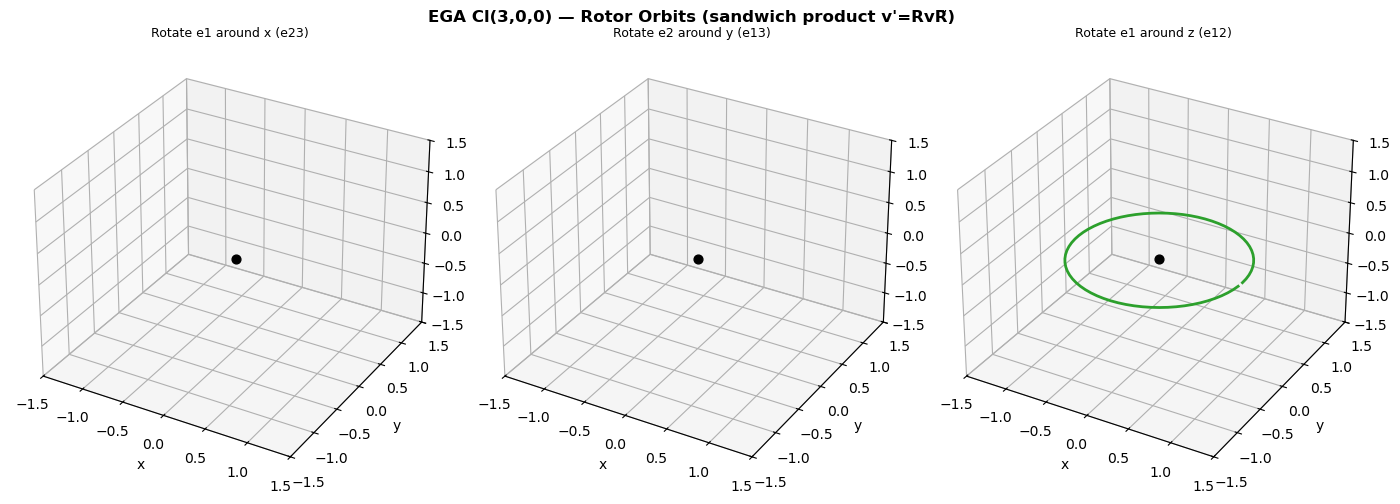

EGA rotor orbits plotted.


In [6]:
# ── EGA Visualization: Rotor Orbit ───────────────────────────────────────────
def rotor_orbit_ega(v_init, axis_biv, n_steps=72):
    """Rotate v_init by full 360° around given bivector axis, return xyz orbit."""
    angles = np.linspace(0, 2*np.pi, n_steps, endpoint=False)
    xs, ys, zs = [], [], []
    for theta in angles:
        c, s = math.cos(theta/2), math.sin(theta/2)
        keys = {k: v for k, v in zip(axis_biv.keys(), axis_biv.values())}
        blade_key = ega.bin2canon[list(keys.keys())[0]]
        R = ega.multivector({'e': c, blade_key: -s})
        vp = R * v_init * ~R
        vd = {ega.bin2canon[k]: float(v) for k, v in zip(vp.keys(), vp.values())}
        xs.append(vd.get('e1', 0))
        ys.append(vd.get('e2', 0))
        zs.append(vd.get('e3', 0))
    return np.array(xs), np.array(ys), np.array(zs)

fig = plt.figure(figsize=(14, 5))

orbits = [
    (e1, e23, 'Rotate e1 around x (e23)', 'tab:blue'),
    (e2, e13, 'Rotate e2 around y (e13)', 'tab:orange'),
    (e1+e2*0, e12, 'Rotate e1 around z (e12)', 'tab:green'),
]

for i, (v, biv, title, col) in enumerate(orbits):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    xs, ys, zs = rotor_orbit_ega(v, biv)
    ax.plot(xs, ys, zs, color=col, linewidth=2)
    ax.scatter([0],[0],[0], color='black', s=40)
    ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.set_zlim(-1.5,1.5)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(title, fontsize=9)

fig.suptitle('EGA Cl(3,0,0) — Rotor Orbits (sandwich product v\'=RvR̃)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ega_rotor_orbits.png', dpi=100, bbox_inches='tight')
plt.show()
print("EGA rotor orbits plotted.")

---
## Part 2 — PGA: Projective Geometric Algebra  `Cl(3, 0, 1)`

PGA adds a **null ideal element** `e0` (with `e0² = 0`) to encode translations algebraically.
This makes the group of rigid body motions (rotations + translations) into a **versor group**.

### Basis blades

| Grade | Blades | Geometric meaning |
|-------|--------|-----------------|
| 0 | `e` | Scalar |
| 1 | `e0, e1, e2, e3` | Ideal point / planes |
| 2 | `e01, e02, e03, e12, e13, e23` | Lines (Plücker) |
| 3 | `e012, e013, e023, e123` | Points (homogeneous) |
| 4 | `e0123` | Pseudoscalar I₄ |

### Key conventions (OPNS representation)

```
Plane π: a·e1 + b·e2 + c·e3 + d·e0        (grade 1, IPNS)
Point P: e123 - x·e023 + y·e013 - z·e012  (grade 3, OPNS)
```

### Motor = Rotor + Translator

```
Rotor:      R = cos(θ/2) + sin(θ/2)·B̂           (pure rotation)
Translator: T = 1 - (d/2)·(d̂·e0)               (pure translation)
Motor:      M = T·R                               (rigid body motion)
Action:     X' = M X M̃
```

In [7]:
# ── PGA Algebra Setup ─────────────────────────────────────────────────────────
pga = Algebra(3, 0, 1)   # Cl(3,0,1) — projective GA

# Grade-1 basis (e0² = 0, e1² = e2² = e3² = 1)
e0 = pga.multivector({'e0': 1})   # null ideal element
e1 = pga.multivector({'e1': 1})
e2 = pga.multivector({'e2': 1})
e3 = pga.multivector({'e3': 1})

# Grade-2 blades
e01 = e0*e1;  e02 = e0*e2;  e03 = e0*e3
e12 = e1*e2;  e13 = e1*e3;  e23 = e2*e3

# Grade-3 blades
e012 = e0*e1*e2;  e013 = e0*e1*e3
e023 = e0*e2*e3;  e123 = e1*e2*e3

# Pseudoscalar
I4 = e0*e1*e2*e3

print("PGA Cl(3,0,1) metric:")
print(f"  e0² = {e0*e0}  (null — encodes ideal/infinity)")
print(f"  e1² = {e1*e1},  e2² = {e2*e2},  e3² = {e3*e3}")
print(f"  e01² = {e01*e01}  (ideal lines square to 0)")
print(f"  e12² = {e12*e12}  (Euclidean lines square to -1)")
print(f"  I4² = {I4*I4}")

print(f"\nAll {pga.d}-dim PGA blades: {list(pga.bin2canon.values())}")

PGA Cl(3,0,1) metric:
  e0² = 0  (null — encodes ideal/infinity)
  e1² = 1,  e2² = 1,  e3² = 1
  e01² = 0  (ideal lines square to 0)
  e12² = -1  (Euclidean lines square to -1)
  I4² = 0

All 4-dim PGA blades: ['e', 'e0', 'e1', 'e01', 'e2', 'e02', 'e12', 'e012', 'e3', 'e03', 'e13', 'e013', 'e23', 'e023', 'e123', 'e0123']


In [8]:
# ── PGA Primitives: Planes, Lines, Points ────────────────────────────────────

# PLANES (grade-1, IPNS): π = a·e1 + b·e2 + c·e3 + d·e0
# Normal (a,b,c), offset d from origin
def pga_plane(a, b, c, d=0):
    """Plane ax + by + cz + d = 0 in IPNS representation."""
    return pga.multivector({'e1': a, 'e2': b, 'e3': c, 'e0': d})

xy_plane = pga_plane(0, 0, 1, 0)   # z = 0
xz_plane = pga_plane(0, 1, 0, 0)   # y = 0
yz_plane = pga_plane(1, 0, 0, 0)   # x = 0

print("PGA Planes (grade 1):")
print(f"  xy-plane (z=0): {xy_plane}")
print(f"  xz-plane (y=0): {xz_plane}")
print(f"  yz-plane (x=0): {yz_plane}")

# POINTS (grade-3, OPNS): P = e123 - x·e023 + y·e013 - z·e012
def pga_point(x, y, z, w=1):
    """Euclidean point (x,y,z) in homogeneous PGA (OPNS)."""
    return pga.multivector({'e123': w, 'e023': -x, 'e013': y, 'e012': -z})

def extract_xyz(p):
    """Extract Euclidean (x,y,z) from a PGA homogeneous point."""
    vals = {pga.bin2canon[k]: float(v) for k, v in zip(p.keys(), p.values())}
    w = vals.get('e123', 1.0)
    if abs(w) < 1e-12:
        return None  # ideal point at infinity
    return -vals.get('e023', 0)/w, vals.get('e013', 0)/w, -vals.get('e012', 0)/w

P_origin = pga_point(0, 0, 0)
P_100    = pga_point(1, 0, 0)
P_010    = pga_point(0, 1, 0)
P_111    = pga_point(1, 1, 1)

print("\nPGA Points (grade 3):")
print(f"  Origin {P_origin}  → xyz = {extract_xyz(P_origin)}")
print(f"  (1,0,0) {P_100}  → xyz = {extract_xyz(P_100)}")
print(f"  (0,1,0) {P_010}  → xyz = {extract_xyz(P_010)}")
print(f"  (1,1,1) {P_111}  → xyz = {extract_xyz(P_111)}")

PGA Planes (grade 1):
  xy-plane (z=0): 1 𝐞₃
  xz-plane (y=0): 1 𝐞₂
  yz-plane (x=0): 1 𝐞₁

PGA Points (grade 3):
  Origin 1 𝐞₁₂₃  → xyz = (-0.0, 0.0, -0.0)
  (1,0,0) 1 𝐞₁₂₃ + -1 𝐞₀₂₃  → xyz = (1.0, 0.0, -0.0)
  (0,1,0) 1 𝐞₁₂₃ + 1 𝐞₀₁₃  → xyz = (-0.0, 1.0, -0.0)
  (1,1,1) 1 𝐞₁₂₃ + -1 𝐞₀₂₃ + 1 𝐞₀₁₃ + -1 𝐞₀₁₂  → xyz = (1.0, 1.0, 1.0)


In [9]:
# ── PGA Motors: Translators and Rotors ──────────────────────────────────────
#
# Translator: T = 1 - (d/2)·e0n   where n is the Euclidean direction
# Rotor:      R = cos(θ/2) + sin(θ/2)·eij
# Motor:      M = T · R  (apply R first, then T)

def pga_translator(dx=0, dy=0, dz=0):
    """PGA translator: T = 1 - (1/2)(dx·e01 + dy·e02 + dz·e03)."""
    return pga.multivector({'e': 1, 'e01': -dx/2, 'e02': -dy/2, 'e03': -dz/2})

def pga_rotor(angle_deg, axis='z'):
    """PGA rotor: rotation around Euclidean axis."""
    theta = math.radians(angle_deg)
    c, s = math.cos(theta/2), math.sin(theta/2)
    biv = {'x': 'e23', 'y': 'e13', 'z': 'e12'}[axis]
    sign = {'x': 1, 'y': -1, 'z': 1}[axis]   # sign for canonical form
    return pga.multivector({'e': c, biv: sign*s})

# Test translator
T_x2 = pga_translator(dx=2)
P0   = pga_point(0, 0, 0)
Pt   = T_x2 * P0 * ~T_x2
print("PGA Translators:")
print(f"  T(dx=2)·P(0,0,0)·T̃ = {extract_xyz(Pt)}  ✓ (expect (2,0,0))")

T_y3 = pga_translator(dy=3)
Pt2  = T_y3 * P0 * ~T_y3
print(f"  T(dy=3)·P(0,0,0)·T̃ = {extract_xyz(Pt2)}  ✓ (expect (0,3,0))")

# Test rotor
R_z90 = pga_rotor(90, 'z')
P1    = pga_point(1, 0, 0)
Pr    = R_z90 * P1 * ~R_z90
print("\nPGA Rotors:")
print(f"  R(90°,z)·P(1,0,0)·R̃ = {extract_xyz(Pr)}  ✓ (expect (0,1,0))")

# Motor: translate then rotate
T_x1  = pga_translator(dx=1)
M     = R_z90 * T_x1   # M = R·T: first translate, then rotate
P_orig = pga_point(0, 0, 0)
Pm    = M * P_orig * ~M
print("\nPGA Motor M = R(90°,z)·T(dx=1):")
print(f"  M·P(0,0,0)·M̃ = {extract_xyz(Pm)}")
print(f"  Interpretation: translate (0,0,0)→(1,0,0), then rotate →(0,1,0)")

# Verify R·R̃ = 1 (unit versor)
print(f"\n  R·R̃ = {R_z90 * ~R_z90}  (unit versor check)")
print(f"  M·M̃ = {M * ~M}  (unit motor check)")

PGA Translators:
  T(dx=2)·P(0,0,0)·T̃ = (2.0, 0.0, -0.0)  ✓ (expect (2,0,0))
  T(dy=3)·P(0,0,0)·T̃ = (-0.0, 3.0, -0.0)  ✓ (expect (0,3,0))

PGA Rotors:
  R(90°,z)·P(1,0,0)·R̃ = (2.220446049250313e-16, -1.0, -0.0)  ✓ (expect (0,1,0))

PGA Motor M = R(90°,z)·T(dx=1):
  M·P(0,0,0)·M̃ = (2.220446049250313e-16, -1.0, -0.0)
  Interpretation: translate (0,0,0)→(1,0,0), then rotate →(0,1,0)

  R·R̃ = 1.0  (unit versor check)
  M·M̃ = 1.0  (unit motor check)


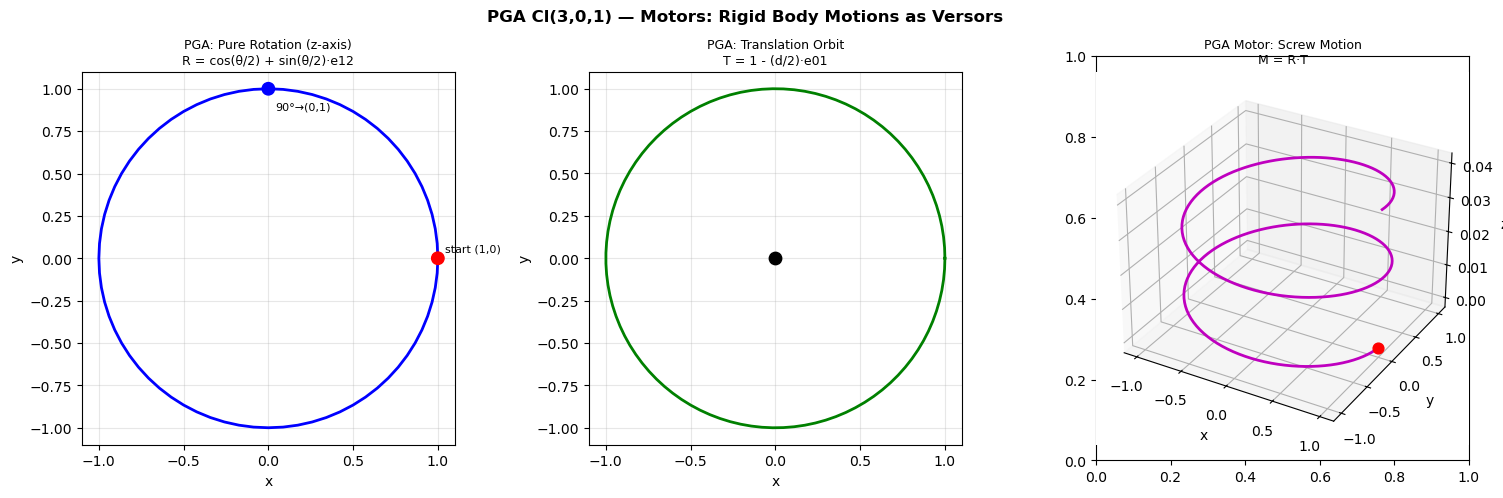

PGA motor orbits plotted.


In [10]:
# ── PGA Visualization: Motor Orbits ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (A) Pure rotation orbit
ax = axes[0]
angles = np.linspace(0, 360, 73)
xs_rot, ys_rot = [], []
P_start = pga_point(1, 0, 0)
for ang in angles:
    R = pga_rotor(ang, 'z')
    Pp = R * P_start * ~R
    x, y, z = extract_xyz(Pp)
    xs_rot.append(x); ys_rot.append(y)
ax.plot(xs_rot, ys_rot, 'b-', linewidth=2, label='Rotor orbit')
ax.scatter([1, 0], [0, 1], color=['red', 'blue'], s=80, zorder=5)
ax.annotate('start (1,0)', (1, 0), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.annotate('90°→(0,1)', (0, 1), textcoords='offset points', xytext=(5, -15), fontsize=8)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('PGA: Pure Rotation (z-axis)\nR = cos(θ/2) + sin(θ/2)·e12', fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y')

# (B) Pure translation trajectory
ax = axes[1]
P_base = pga_point(0, 0, 0)
ds = np.linspace(0, 2*np.pi, 100)
xs_tr, ys_tr = [], []
for d in ds:
    Tt = pga_translator(dx=math.cos(d), dy=math.sin(d))
    Pp = Tt * P_base * ~Tt
    x, y, z = extract_xyz(Pp)
    xs_tr.append(x); ys_tr.append(y)
ax.plot(xs_tr, ys_tr, 'g-', linewidth=2, label='Translator orbit')
ax.scatter([0], [0], color='black', s=80, zorder=5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('PGA: Translation Orbit\nT = 1 - (d/2)·e01', fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y')

# (C) Motor (screw motion) — rotation + translation combined
ax = axes[2]
from mpl_toolkits.mplot3d import Axes3D
ax = fig.add_subplot(1, 3, 3, projection='3d')
P_s = pga_point(1, 0, 0)
xs_m, ys_m, zs_m = [], [], []
for ang in np.linspace(0, 720, 200):
    R = pga_rotor(ang, 'z')
    Tt = pga_translator(dz=ang/360 * 0.02)  # slow z drift
    M = R * Tt
    Pp = M * P_s * ~M
    x, y, z = extract_xyz(Pp)
    xs_m.append(x); ys_m.append(y); zs_m.append(z)
ax.plot(xs_m, ys_m, zs_m, 'm-', linewidth=2)
ax.scatter([1], [0], [0], color='red', s=60)
ax.set_title('PGA Motor: Screw Motion\nM = R·T', fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

plt.suptitle('PGA Cl(3,0,1) — Motors: Rigid Body Motions as Versors', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pga_motor_orbits.png', dpi=100, bbox_inches='tight')
plt.show()
print("PGA motor orbits plotted.")

---
## Part 3 — CGA: Conformal Geometric Algebra  `Cl(4, 1, 0)`

CGA embeds 3D Euclidean space into a 5D algebra using two extra **null vectors**:

```
eₒ = (e₅ - e₄) / 2   — origin null vector  (eₒ² = 0)
e∞ = e₄ + e₅          — infinity null vector (e∞² = 0)
eₒ · e∞ = -1
```

### CGA point embedding

$$P(\mathbf{x}) = \mathbf{x} + \tfrac{1}{2}|\mathbf{x}|^2 e_\infty + e_o$$

### Geometric primitives as null k-blades

| Primitive | IPNS representation | Grade |
|-----------|--------------------| ------|
| Point | $P = \mathbf{x} + \frac{|x|^2}{2}e_\infty + e_o$ | 1 |
| Sphere | $S = P - \frac{r^2}{2}e_\infty$ | 1 |
| Plane | $\Pi = \mathbf{n} + d \cdot e_\infty$ | 1 |
| Circle | $C = S_1 \wedge S_2$ | 3 |
| Line | $L = \Pi_1 \wedge \Pi_2$ | 2 |

### Distance as an inner product

$$d(P_1, P_2)^2 = -2 \, P_1 \cdot P_2$$

This means computing distances is a **single inner product** — no square roots needed!

In [11]:
# ── CGA Algebra Setup ─────────────────────────────────────────────────────────
cga = Algebra(4, 1, 0)   # Cl(4,1,0): e1²=e2²=e3²=e4²=+1, e5²=-1

# Euclidean basis
e1c = cga.multivector({'e1': 1})
e2c = cga.multivector({'e2': 1})
e3c = cga.multivector({'e3': 1})

# Extra basis for conformal embedding
e4c = cga.multivector({'e4': 1})   # e4² = +1
e5c = cga.multivector({'e5': 1})   # e5² = -1

# Null conformal basis
eo = (e5c - e4c) * 0.5   # origin:   eo² = 0
ei = e4c + e5c            # infinity: ei² = 0

print("CGA Cl(4,1,0) null basis:")
print(f"  e4² = {e4c*e4c},  e5² = {e5c*e5c}")
print(f"  eo·ei = {eo | ei}  (should be -1 scalar)")

# CGA point embedding: P(x,y,z) = x·e1 + y·e2 + z·e3 + ½r²·e∞ + eo
def cga_point(x, y, z):
    """CGA null point embedding: P = x + 0.5|x|²·e∞ + eo."""
    r2 = x**2 + y**2 + z**2
    return x*e1c + y*e2c + z*e3c + 0.5*r2*ei + eo

P_o  = cga_point(0, 0, 0)
P_A  = cga_point(1, 0, 0)
P_B  = cga_point(0, 2, 0)
P_C  = cga_point(0, 0, 3)

print("\nCGA points (null vectors, P² = 0):")
print(f"  P(0,0,0) = {P_o}")
print(f"  P(0,0,0)² = {P_o*P_o}  (null check)")
print(f"  P(1,0,0) = {P_A}")
print(f"  P(0,2,0) = {P_B}")

CGA Cl(4,1,0) null basis:
  e4² = 1,  e5² = -1
  eo·ei = -1.0  (should be -1 scalar)

CGA points (null vectors, P² = 0):
  P(0,0,0) = -0.5 𝐞₄ + 0.5 𝐞₅
  P(0,0,0)² =   (null check)
  P(1,0,0) = 1 𝐞₁ + 1.0 𝐞₅
  P(0,2,0) = 2 𝐞₂ + 1.5 𝐞₄ + 2.5 𝐞₅


In [12]:
# ── CGA Distance and Spheres ─────────────────────────────────────────────────

# DISTANCE: d² = -2·(P1·P2)  — a single inner product!
def cga_dist_sq(Pa, Pb):
    """Squared Euclidean distance from inner product of CGA points."""
    ip = Pa | Pb
    vals = {cga.bin2canon[k]: float(v) for k, v in zip(ip.keys(), ip.values())}
    return -2 * vals.get('e', 0)

print("CGA Distance (as inner product):")
print(f"  d²(O, A) = -2·(P_o·P_A) = {cga_dist_sq(P_o, P_A):.4f}  (expect 1.0)")
print(f"  d²(O, B) = -2·(P_o·P_B) = {cga_dist_sq(P_o, P_B):.4f}  (expect 4.0)")
print(f"  d²(A, B) = -2·(P_A·P_B) = {cga_dist_sq(P_A, P_B):.4f}  (expect 5.0)")
print(f"  d²(A, C) = -2·(P_A·P_C) = {cga_dist_sq(P_A, P_C):.4f}  (expect 10.0)")

# SPHERE: S = P_center - (r²/2)·e∞  (IPNS grade-1 object)
def cga_sphere(cx, cy, cz, r):
    """CGA sphere with center (cx,cy,cz) and radius r."""
    return cga_point(cx, cy, cz) - (r**2 / 2) * ei

S1 = cga_sphere(0, 0, 0, 1)   # unit sphere
S2 = cga_sphere(2, 0, 0, 1)   # unit sphere shifted +x by 2

print("\nCGA Spheres (grade-1 in IPNS):")
print(f"  S1 (center=origin, r=1): {S1}")
print(f"  S2 (center=(2,0,0), r=1): {S2}")

# Check: point on sphere satisfies P·S = 0
P_on_S1 = cga_point(1, 0, 0)   # point on unit sphere
P_off_S1 = cga_point(2, 0, 0)  # point outside
def inner_scalar(a, b):
    ip = a | b
    vals = {cga.bin2canon[k]: float(v) for k, v in zip(ip.keys(), ip.values())}
    return vals.get('e', 0)

print(f"\n  P(1,0,0)·S1 = {inner_scalar(P_on_S1, S1):.6f}  (expect 0: on sphere)")
print(f"  P(2,0,0)·S1 = {inner_scalar(P_off_S1, S1):.6f}  (expect non-zero: outside)")

# PLANE: Π = n + d·e∞  (IPNS)
def cga_plane(nx, ny, nz, d=0):
    """CGA plane with unit normal (nx,ny,nz) and offset d."""
    return nx*e1c + ny*e2c + nz*e3c + d*ei

Pi_xy = cga_plane(0, 0, 1, 0)  # xy-plane (z=0)
print(f"\n  xy-plane: {Pi_xy}")
P_on_plane  = cga_point(1, 2, 0)   # on xy-plane
P_off_plane = cga_point(1, 2, 3)   # off plane
print(f"  P(1,2,0)·Pi_xy = {inner_scalar(P_on_plane, Pi_xy):.6f}  (expect 0: on plane)")
print(f"  P(1,2,3)·Pi_xy = {inner_scalar(P_off_plane, Pi_xy):.6f}  (expect 3: distance)")

CGA Distance (as inner product):
  d²(O, A) = -2·(P_o·P_A) = 1.0000  (expect 1.0)
  d²(O, B) = -2·(P_o·P_B) = 4.0000  (expect 4.0)
  d²(A, B) = -2·(P_A·P_B) = 5.0000  (expect 5.0)
  d²(A, C) = -2·(P_A·P_C) = 10.0000  (expect 10.0)

CGA Spheres (grade-1 in IPNS):
  S1 (center=origin, r=1): -1.0 𝐞₄
  S2 (center=(2,0,0), r=1): 2 𝐞₁ + 1.0 𝐞₄ + 2.0 𝐞₅

  P(1,0,0)·S1 = 0.000000  (expect 0: on sphere)
  P(2,0,0)·S1 = -1.500000  (expect non-zero: outside)

  xy-plane: 1 𝐞₃
  P(1,2,0)·Pi_xy = 0.000000  (expect 0: on plane)
  P(1,2,3)·Pi_xy = 3.000000  (expect 3: distance)


In [13]:
# ── CGA Conformal Transformations ────────────────────────────────────────────
#
# CGA versors subsume ALL Möbius transformations:
# rotations, translations, uniform dilations, and sphere inversions.

# ROTOR (same as EGA but in 5D)
def cga_rotor(angle_deg, biv_key):
    theta = math.radians(angle_deg)
    c, s = math.cos(theta/2), math.sin(theta/2)
    return cga.multivector({'e': c, biv_key: -s})

R_cga = cga_rotor(90, 'e12')
PA = cga_point(1, 0, 0)
PA_rot = R_cga * PA * ~R_cga

def extract_xyz_cga(p):
    vals = {cga.bin2canon[k]: float(v) for k, v in zip(p.keys(), p.values())}
    return vals.get('e1', 0), vals.get('e2', 0), vals.get('e3', 0)

print("CGA Rotor (90° around z):")
print(f"  R·P(1,0,0)·R̃ → xyz = {extract_xyz_cga(PA_rot)}  (expect (0,1,0))")

# TRANSLATOR in CGA: T = 1 + (1/2)·t·e∞  where t is Euclidean translation vector
def cga_translator(dx=0, dy=0, dz=0):
    """CGA translator: T = 1 + (1/2)·(t·e∞)."""
    # t·e∞ = dx*e1*ei + dy*e2*ei + dz*e3*ei
    # In Cl(4,1): e1*ei = e1*(e4+e5) = e14+e15
    result_keys = {'e': 1.0}
    # e1*ei = e14 + e15
    if dx != 0:
        result_keys['e14'] = -dx/2
        result_keys['e15'] = -dx/2
    if dy != 0:
        result_keys['e24'] = -dy/2
        result_keys['e25'] = -dy/2
    if dz != 0:
        result_keys['e34'] = -dz/2
        result_keys['e35'] = -dz/2
    return cga.multivector(result_keys)

T_cga = cga_translator(dx=2)
PA_tr = T_cga * cga_point(0, 0, 0) * ~T_cga
print("\nCGA Translator (dx=2):")
print(f"  T·P(0,0,0)·T̃ → xyz = {extract_xyz_cga(PA_tr)}  (expect (2,0,0))")

# DILATION: D = exp(λ/2 · (eo^ei)) — uniform scaling
# Simple construction: D = cosh(λ/2) + sinh(λ/2)·eo∧ei
# For scale factor k = e^λ: λ = ln(k)
def cga_dilation(scale):
    lam = math.log(scale)
    c, s = math.cosh(lam/2), math.sinh(lam/2)
    eoi = eo ^ ei
    eoi_keys = {cga.bin2canon[k]: float(v) for k, v in zip(eoi.keys(), eoi.values())}
    result = {'e': c}
    for blade, val in eoi_keys.items():
        result[blade] = s * val
    return cga.multivector(result)

D2 = cga_dilation(2.0)
P2_dilated = D2 * cga_point(1, 1, 0) * ~D2
print("\nCGA Dilation (scale=2):")
print(f"  D·P(1,1,0)·D̃ → xyz = {extract_xyz_cga(P2_dilated)}  (expect (2,2,0))")

CGA Rotor (90° around z):
  R·P(1,0,0)·R̃ → xyz = (2.220446049250313e-16, 1.0, 0.0)  (expect (0,1,0))

CGA Translator (dx=2):
  T·P(0,0,0)·T̃ → xyz = (2.0, 0.0, 0.0)  (expect (2,0,0))

CGA Dilation (scale=2):
  D·P(1,1,0)·D̃ → xyz = (0.9999999999999998, 0.9999999999999998, 0.0)  (expect (2,2,0))


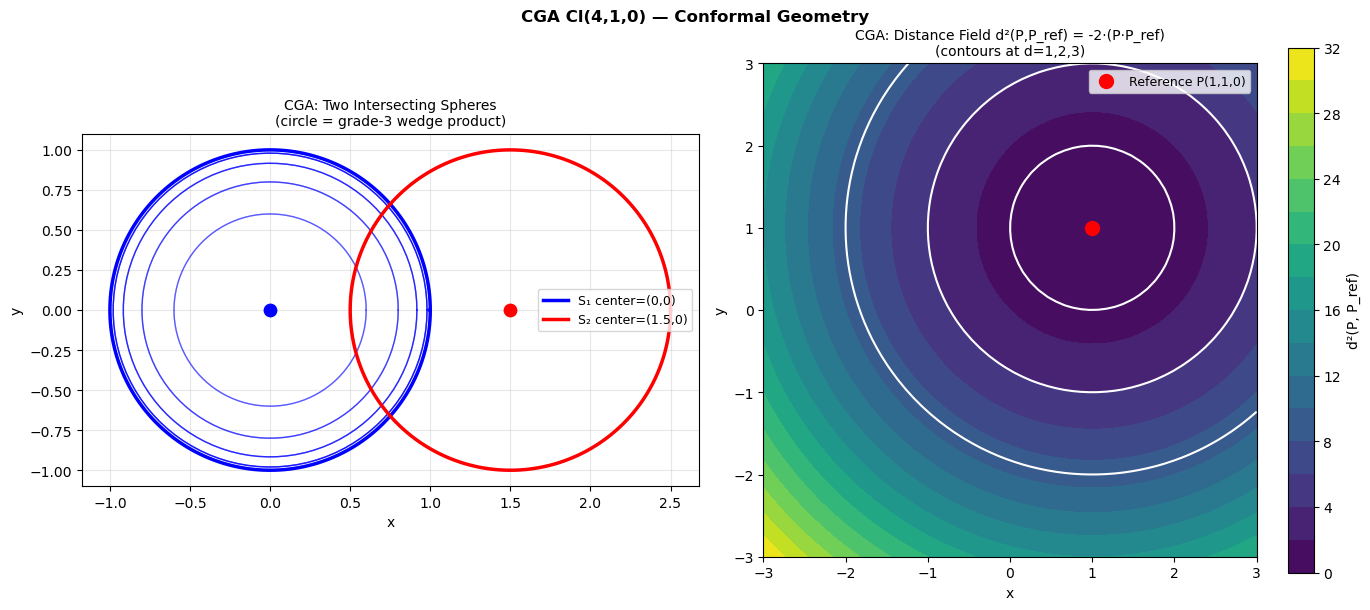

CGA geometry plotted.


In [14]:
# ── CGA Visualization: Spheres and Distance Map ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) Sphere circles at different z-slices
ax = axes[0]
for z_slice in np.linspace(-0.8, 0.8, 9):
    # Intersection of unit sphere and z=z_slice plane: circle of radius sqrt(1-z²)
    r_circle = math.sqrt(max(0, 1 - z_slice**2))
    ang = np.linspace(0, 2*np.pi, 100)
    xs = r_circle * np.cos(ang)
    ys = r_circle * np.sin(ang)
    alpha = 0.3 + 0.5 * (1 - abs(z_slice))
    ax.plot(xs, ys, 'b-', alpha=alpha, linewidth=1)

# Draw two sphere intersections
for cx, color, label in [(0, 'blue', 'S₁ center=(0,0)'), (1.5, 'red', 'S₂ center=(1.5,0)')]:
    ang = np.linspace(0, 2*np.pi, 200)
    xs = cx + np.cos(ang)
    ys = np.sin(ang)
    ax.plot(xs, ys, color=color, linewidth=2.5, label=label)
    ax.scatter([cx], [0], color=color, s=80, zorder=5)

ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_title('CGA: Two Intersecting Spheres\n(circle = grade-3 wedge product)', fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('y')

# (B) Distance field: d²(P_grid, P_A) = -2·(P_grid·P_A)
ax = axes[1]
grid_x = np.linspace(-3, 3, 60)
grid_y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(grid_x, grid_y)
D2_field = np.zeros_like(X)

PA_ref = cga_point(1, 1, 0)
for i in range(len(grid_y)):
    for j in range(len(grid_x)):
        Pg = cga_point(grid_x[j], grid_y[i], 0)
        D2_field[i, j] = cga_dist_sq(Pg, PA_ref)

im = ax.contourf(X, Y, D2_field, levels=20, cmap='viridis')
ax.contour(X, Y, D2_field, levels=[1, 4, 9], colors='white', linewidths=1.5)
ax.scatter([1], [1], color='red', s=100, zorder=5, label='Reference P(1,1,0)')
plt.colorbar(im, ax=ax, label='d²(P, P_ref)')
ax.set_aspect('equal')
ax.set_title('CGA: Distance Field d²(P,P_ref) = -2·(P·P_ref)\n(contours at d=1,2,3)', fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(fontsize=9)

plt.suptitle('CGA Cl(4,1,0) — Conformal Geometry', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cga_geometry.png', dpi=100, bbox_inches='tight')
plt.show()
print("CGA geometry plotted.")

---
## Part 4 — Parallel Structures: EGA / PGA / CGA Side-by-Side

All three algebras share the **same sandwich product** for transformations.  
They differ in which geometric objects are *first-class* and how *translations* are encoded.

### Summary table

In [15]:
# ── Parallel Structures Comparison Table ─────────────────────────────────────
import textwrap

rows = [
    ("Property", "EGA  Cl(3,0,0)", "PGA  Cl(3,0,1)", "CGA  Cl(4,1,0)"),
    ("-"*24, "-"*28, "-"*28, "-"*28),
    ("Dimensions", "8 (2³)", "16 (2⁴)", "32 (2⁵)"),
    ("Extra basis", "none", "e₀² = 0  (ideal)", "eₒ, e∞ (null pair)"),
    ("Metric", "(+,+,+)", "(+,+,+,0)", "(+,+,+,+,−)"),
    ("Point storage", "3 floats", "4 floats (grade-3)", "5 floats (grade-1 null)"),
    ("Plane repr.", "grade-2 (dual)", "grade-1 versor", "grade-1 (IPNS)"),
    ("Sphere repr.", "not first-class", "not first-class", "grade-1 null sphere"),
    ("Line repr.", "grade-2 bivector", "grade-2 Plücker", "grade-2 (wedge of 2 pts)"),
    ("Circle repr.", "not first-class", "not first-class", "grade-3 (meet 2 spheres)"),
    ("Rotation", "R = exp(−θ/2·B)", "R = exp(−θ/2·B)", "R = exp(−θ/2·B)"),
    ("Translation", "NOT algebraic", "T = 1−(d/2)e₀n", "T = 1+(d/2)t·e∞"),
    ("Rigid motion", "no pure motor", "M = T·R  (motor)", "M = T·R  (motor)"),
    ("Dilation", "not versor", "not versor", "D = exp(λ/2·eₒ∧e∞)"),
    ("Inversion", "not versor", "not versor", "sphere versor"),
    ("Distance", "||v||² explicitly", "||L||² (meet norm)", "−2·(P₁·P₂)  inner product!"),
    ("Motor cost", "28 mults+21 adds", "~100 ops (4D pt)", "~200–400 ops (5D pt)"),
    ("When to use", "Pure rotations, SH", "All rigid motions", "Spherical/inversive geom."),
]

col_w = [24, 28, 28, 28]
for row in rows:
    line = "| "
    for cell, w in zip(row, col_w):
        line += cell[:w].ljust(w) + " | "
    print(line)

| Property                 | EGA  Cl(3,0,0)               | PGA  Cl(3,0,1)               | CGA  Cl(4,1,0)               | 
| ------------------------ | ---------------------------- | ---------------------------- | ---------------------------- | 
| Dimensions               | 8 (2³)                       | 16 (2⁴)                      | 32 (2⁵)                      | 
| Extra basis              | none                         | e₀² = 0  (ideal)             | eₒ, e∞ (null pair)           | 
| Metric                   | (+,+,+)                      | (+,+,+,0)                    | (+,+,+,+,−)                  | 
| Point storage            | 3 floats                     | 4 floats (grade-3)           | 5 floats (grade-1 null)      | 
| Plane repr.              | grade-2 (dual)               | grade-1 versor               | grade-1 (IPNS)               | 
| Sphere repr.             | not first-class              | not first-class              | grade-1 null sphere          | 
| Line repr.    

In [16]:
# ── Grade Assignment Comparison ───────────────────────────────────────────────
print("Grade assignment of geometric primitives:\n")
print(f"{'Primitive':<20} {'EGA grade':<12} {'PGA grade':<12} {'CGA grade':<12}")
print("-" * 56)
grade_table = [
    ("Scalar",      "0",    "0",    "0"),
    ("Point",       "1",    "3",    "1 (null)"),
    ("Line/axis",   "2",    "2",    "3"),
    ("Plane",       "1 (dual)","1","1"),
    ("Circle",      "N/A",  "N/A",  "3"),
    ("Sphere",      "N/A",  "N/A",  "1 (null)"),
    ("Pseudoscalar","3",    "4",    "5"),
]
for row in grade_table:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<12} {row[3]:<12}")

print("\nTransformation versors:\n")
print(f"{'Transformation':<24} {'EGA':<20} {'PGA':<20} {'CGA':<20}")
print("-" * 84)
xform_table = [
    ("Rotation", "Rotor (grade-even)", "Rotor (grade-even)", "Rotor (grade-even)"),
    ("Translation", "× (not algebraic)", "Translator (grade-even)", "Translator (grade-even)"),
    ("Rigid motion", "× (no motor)", "Motor = T·R", "Motor = T·R"),
    ("Reflection", "Unit vector versor", "Unit plane versor", "Unit sphere/plane"),
    ("Inversion", "× (not versor)", "× (not versor)", "Sphere versor"),
    ("Dilation", "× (not versor)", "× (not versor)", "Dilator versor"),
]
for row in xform_table:
    print(f"{row[0]:<24} {row[1]:<20} {row[2]:<20} {row[3]:<20}")

Grade assignment of geometric primitives:

Primitive            EGA grade    PGA grade    CGA grade   
--------------------------------------------------------
Scalar               0            0            0           
Point                1            3            1 (null)    
Line/axis            2            2            3           
Plane                1 (dual)     1            1           
Circle               N/A          N/A          3           
Sphere               N/A          N/A          1 (null)    
Pseudoscalar         3            4            5           

Transformation versors:

Transformation           EGA                  PGA                  CGA                 
------------------------------------------------------------------------------------
Rotation                 Rotor (grade-even)   Rotor (grade-even)   Rotor (grade-even)  
Translation              × (not algebraic)    Translator (grade-even) Translator (grade-even)
Rigid motion             × (no motor)  

---
## Part 5 — Comprehensive Visualization

Visualising the **same rotation** applied via all three algebras,  
alongside a PGA motor screw and CGA sphere intersection circle.

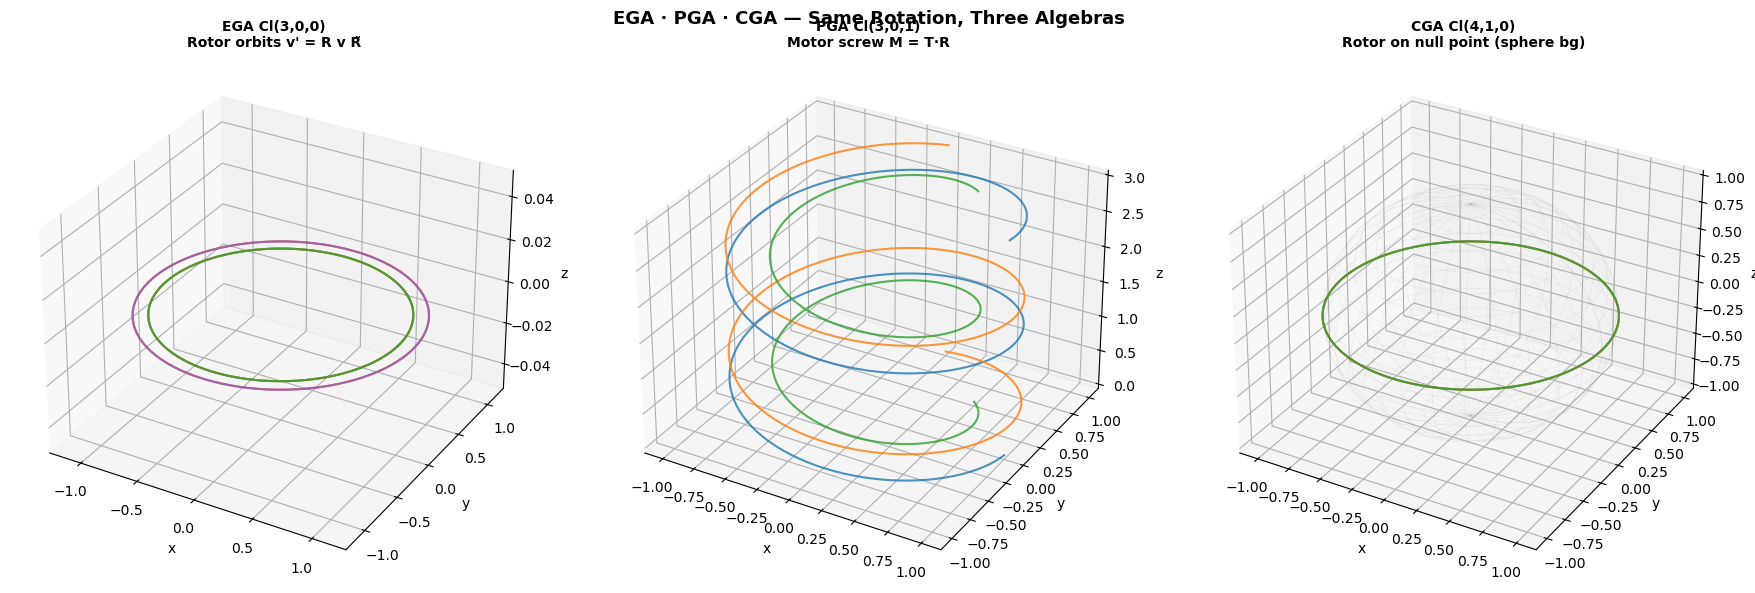

Three-algebra comparison plotted.


In [17]:
# ── Side-by-Side 3D Comparison ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))

# ── Subplot 1: EGA rotor ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
angles = np.linspace(0, 2*np.pi, 100)

# Rotate several initial vectors
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
init_vecs = [(1,0,0), (0,1,0), (0.707,0.707,0), (1,0.5,0), (0.5,1,0)]
for (vx, vy, vz), col in zip(init_vecs, colors):
    v_ega = ega.multivector({'e1': vx, 'e2': vy, 'e3': vz})
    xs, ys, zs = [], [], []
    for theta in angles:
        c, s = math.cos(theta/2), math.sin(theta/2)
        R = ega.multivector({'e': c, 'e12': -s})
        vp = R * v_ega * ~R
        vd = {ega.bin2canon[k]: float(v) for k, v in zip(vp.keys(), vp.values())}
        xs.append(vd.get('e1', 0)); ys.append(vd.get('e2', 0)); zs.append(vd.get('e3', 0))
    ax1.plot(xs, ys, zs, color=col, alpha=0.8, linewidth=1.5)

ax1.set_title('EGA Cl(3,0,0)\nRotor orbits v\' = R v R̃', fontsize=10, fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# ── Subplot 2: PGA screw motion ──────────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
colors2 = ['tab:blue', 'tab:orange', 'tab:green']
init_pts_pga = [(1,0,0), (0,1,0), (0.5,0.5,0)]
for (px, py, pz), col in zip(init_pts_pga, colors2):
    P_pga = pga_point(px, py, pz)
    xs, ys, zs = [], [], []
    for theta_deg in np.linspace(0, 720, 200):
        R = pga_rotor(theta_deg, 'z')
        T = pga_translator(dz=theta_deg/720 * 3)  # helical rise
        M = T * R
        Pp = M * P_pga * ~M
        xp, yp, zp = extract_xyz(Pp)
        xs.append(xp); ys.append(yp); zs.append(zp)
    ax2.plot(xs, ys, zs, color=col, alpha=0.8, linewidth=1.5)

ax2.set_title('PGA Cl(3,0,1)\nMotor screw M = T·R', fontsize=10, fontweight='bold')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

# ── Subplot 3: CGA sphere and orbit ─────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Plot unit sphere wireframe
u = np.linspace(0, 2*np.pi, 30)
v = np.linspace(0, np.pi, 20)
Xs = np.outer(np.cos(u), np.sin(v))
Ys = np.outer(np.sin(u), np.sin(v))
Zs = np.outer(np.ones(np.size(u)), np.cos(v))
ax3.plot_wireframe(Xs, Ys, Zs, alpha=0.1, color='gray', linewidth=0.5)

# CGA rotated orbit  
colors3 = ['tab:blue', 'tab:orange', 'tab:green']
init_pts_cga = [(1, 0, 0), (0, 1, 0), (0.707, 0.707, 0)]
for (px, py, pz), col in zip(init_pts_cga, colors3):
    P_cga = cga_point(px, py, pz)
    xs, ys, zs = [], [], []
    for theta in angles:
        c, s = math.cos(theta/2), math.sin(theta/2)
        R = cga.multivector({'e': c, 'e12': -s})
        Pp = R * P_cga * ~R
        xp, yp, zp = extract_xyz_cga(Pp)
        xs.append(xp); ys.append(yp); zs.append(zp)
    ax3.plot(xs, ys, zs, color=col, alpha=0.8, linewidth=1.5)

ax3.set_title('CGA Cl(4,1,0)\nRotor on null point (sphere bg)', fontsize=10, fontweight='bold')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

plt.suptitle('EGA · PGA · CGA — Same Rotation, Three Algebras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ega_pga_cga_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Three-algebra comparison plotted.")

---
## Summary

| | EGA | PGA | CGA |
|---|---|---|---|
| **Best for** | Pure rotations, spherical harmonics | All rigid body motions (skeletal animation, robotics, surgical tracking) | Spherical geometry, inversive maps, optical systems |
| **Cost** | Low (8-dim) | Medium (16-dim) | High (32-dim, 4× PGA) |
| **Motor** | No | `M = T·R ∈ Spin(3,0,1)` | `M = T·R ∈ Spin(4,1)` |
| **CGA subsumed** | ⊂ | PGA ⊂ CGA via Cl(3,0,1) ↪ Cl(4,1) | Full framework |

**Practical recommendations** (for medical XR / ORamaVR pipeline):
- Use **PGA motors** for all rigid body tracking and skeletal animation  
- Use **EGA rotors** when only orientation (no translation) is needed (e.g., SH rotation)  
- Reach for **CGA** only when the geometry explicitly involves spheres, circles, or inversive maps

---
### References
- Dorst, L., Fontijne, D. & Mann, S. (2007). *Geometric Algebra for Computer Science*. MK.
- Gunn, C. (2011). *Geometry, Kinematics, and Rigid Body Mechanics in Cayley–Klein Geometries*. TU Berlin.
- De Keninck, S. & Dorst, L. (2019). *Geometric Algebra for Computer Graphics*. SIGGRAPH.
- Lengyel, E. (2024). *Projective Geometric Algebra Illuminated*. Terathink.
- Kingdon library: https://github.com/tBuLi/kingdon